# **Project 2: In-Depth Exploratory Data Analysis (EDA)**
# Netflix Content Analysis 🎬
Project Objective: To perform an in-depth exploratory data analysis of the Netflix dataset. We will explore trends in content production, identify popular genres, analyze content ratings, and understand the distribution of movies and TV shows on the platform. This project builds on foundational EDA by introducing time-series analysis and more complex data cleaning and transformation techniques.

In [ ]:
!git clone https://github.com/GeeksforgeeksDS/21-Days-21-Projects-Dataset.git

fatal: destination path '21-Days-21-Projects-Dataset' already exists and is not an empty directory.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv("/content/21-Days-21-Projects-Dataset/Datasets/netflix_titles.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
df.shape

(7787, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
#Checking the missing values :
df.isna().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


In [ ]:
#Cleaning the director  and cast column - filling with unknown
df["director"]=df["director"].fillna('Unknown')
df["cast"]=df["cast"].fillna('Unknown')
df.isna().sum().sort_values(ascending=False)

,0
country,507
date_added,10
rating,7
show_id,0
director,0
title,0
type,0
cast,0
release_year,0
duration,0


In [ ]:
#cleaning the country column - filling with the mode value
df['country']=df['country'].fillna(df['country'].mode()[0])
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
#Now we have rating and date_added column left to clean
#Since the number is less , we can simply drop the rows

df=df.dropna(subset=["date_added" , "rating"])
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.1+ KB


In [ ]:
#Exrtracting New Columns from the Date_Added

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  year_added    7770 non-null   int32         
 13  month_added   7770 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
memory usage: 849.8+ KB


In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10


**Q.1 What is the distribution of content type?**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
 12  year_added    7770 non-null   int32         
 13  month_added   7770 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
memory usage: 849.8+ KB


In [ ]:
df.type.value_counts()

,count
type,
Movie,5372
TV Show,2398


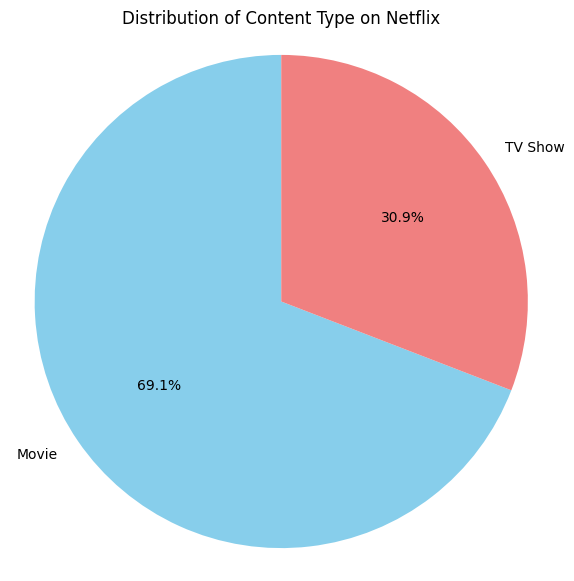

In [ ]:
content_type_counts = df['type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(content_type_counts, labels=content_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Content Type on Netflix')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Insight:

---
- Movie covers around 70% of the Netflix content whereas , TV Show covers only 30%.


**Q.2 How has content been added over time?**

<Figure size 1400x800 with 0 Axes>

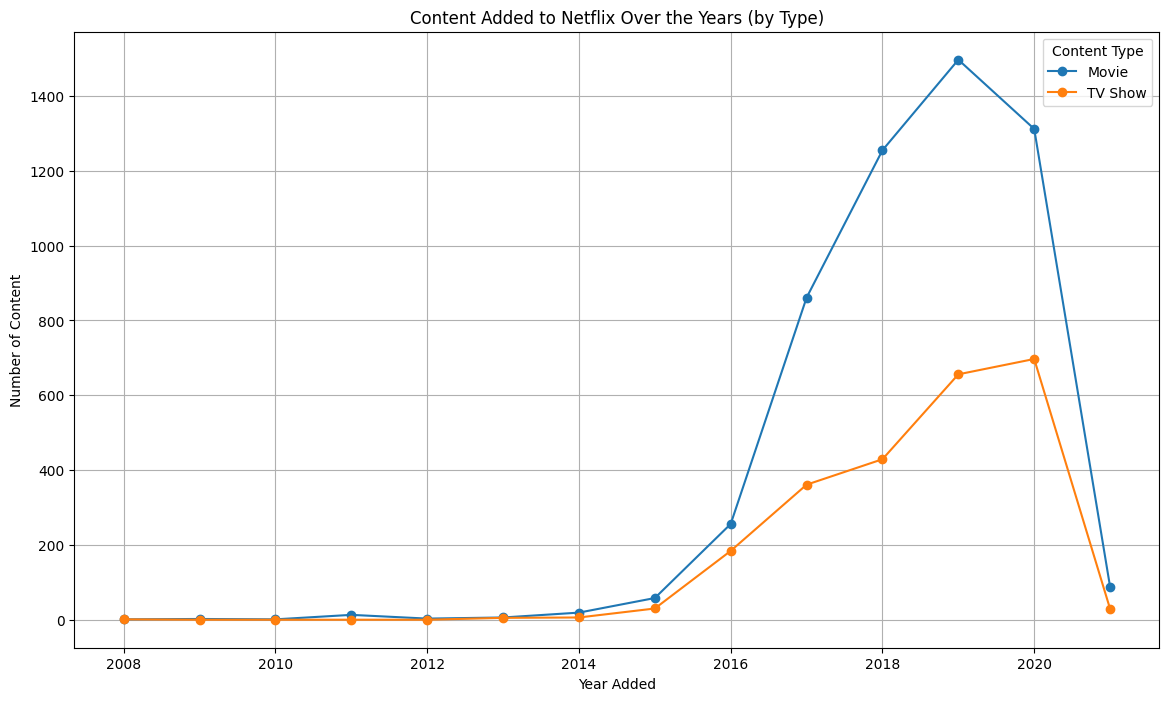

In [ ]:
#We can create a figure representing the year and type of content
#Maybe a scatter plot over year for two types of content movie and Tv show

content_over_time = df.groupby(['year_added','type']).size().unstack().fillna(0)
plt.figure(figsize=(14, 8))
content_over_time.plot(kind="line" , marker='o' , figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Content')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

Insights :

---
-In the early period of netflix the number of TV show and Movies were similar and low. However, starting from year 2014, the quantity of both content types started to rise significantly, where movies had a drastic increase till 2019. Yet, A major decline can be seen for both movies and tv shows in the year 2020-2021 probably because of COVID-19.


**Q.3 What are the most popular genres?**

In [ ]:
df['listed_in'].value_counts()

,count
listed_in,
Documentaries,334
Stand-Up Comedy,321
"Dramas, International Movies",320
"Comedies, Dramas, International Movies",243
"Dramas, Independent Movies, International Movies",215
...,...
Sports Movies,1
"Crime TV Shows, TV Horror, TV Mysteries",1
"Children & Family Movies, Classic Movies, Dramas",1


In [ ]:
# Split the 'listed_in' column and explode it
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
genres["genre"].value_counts()

,count
genre,
International Movies,2437
Dramas,2105
Comedies,1471
International TV Shows,1197
Documentaries,786
Action & Adventure,721
TV Dramas,703
Independent Movies,673
Children & Family Movies,532


In [ ]:
top_genres = genres['genre'].value_counts().reset_index()
top_genres.columns = ['genre','count']

Text(0, 0.5, 'Genre')

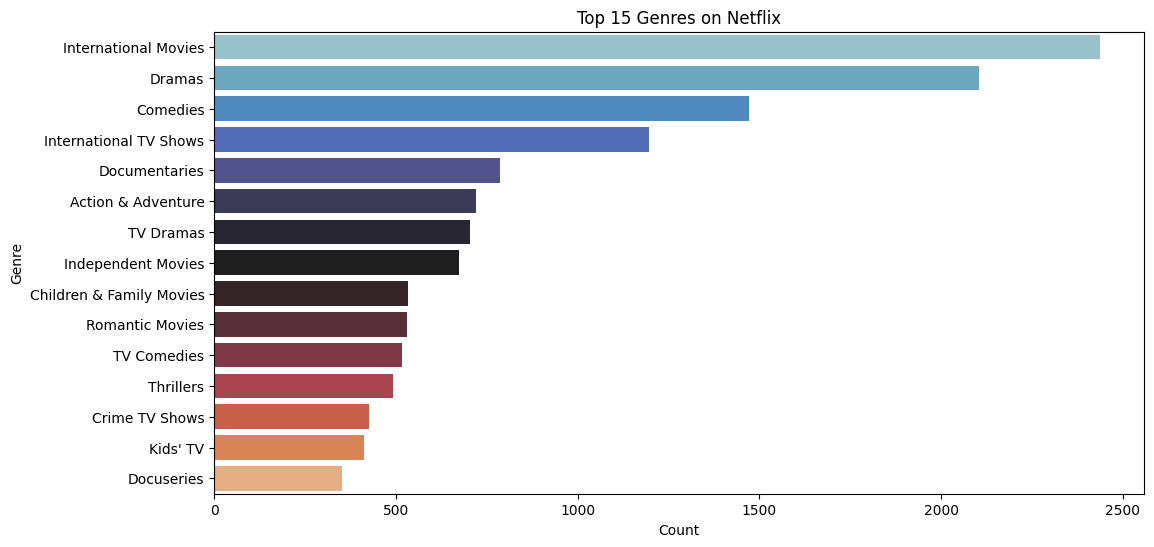

In [ ]:
top_15_genres = top_genres.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y='genre', x='count', data=top_15_genres, palette='icefire', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')

Insights :

---
- Most popular genre on Netflix is International Movies. Follwing that there is Dramas , Comedies and International TV Shows as the most common ones.



**Q.4 What is the distribution of content duration?**

In [ ]:
df['duration'].value_counts()

,count
duration,
1 Season,1606
2 Seasons,378
3 Seasons,183
90 min,136
93 min,131
...,...
36 min,1
201 min,1
253 min,1


In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [ ]:

# duration has two format - seasons (TV shows) and mins (Movies)
tv_shows_df["seasons"] = df[df['type'] == 'TV Show']['duration'].str.replace(' Seasons', '').str.replace(' Season' , '').astype(int)
tv_shows_df.head(2)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,seasons
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,4
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,2017,7,1


In [ ]:
movies_df["duration_time"] = df[df['type']=="Movie"]['duration'].str.replace(' min','').astype(int)
movies_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_time
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,93
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,78


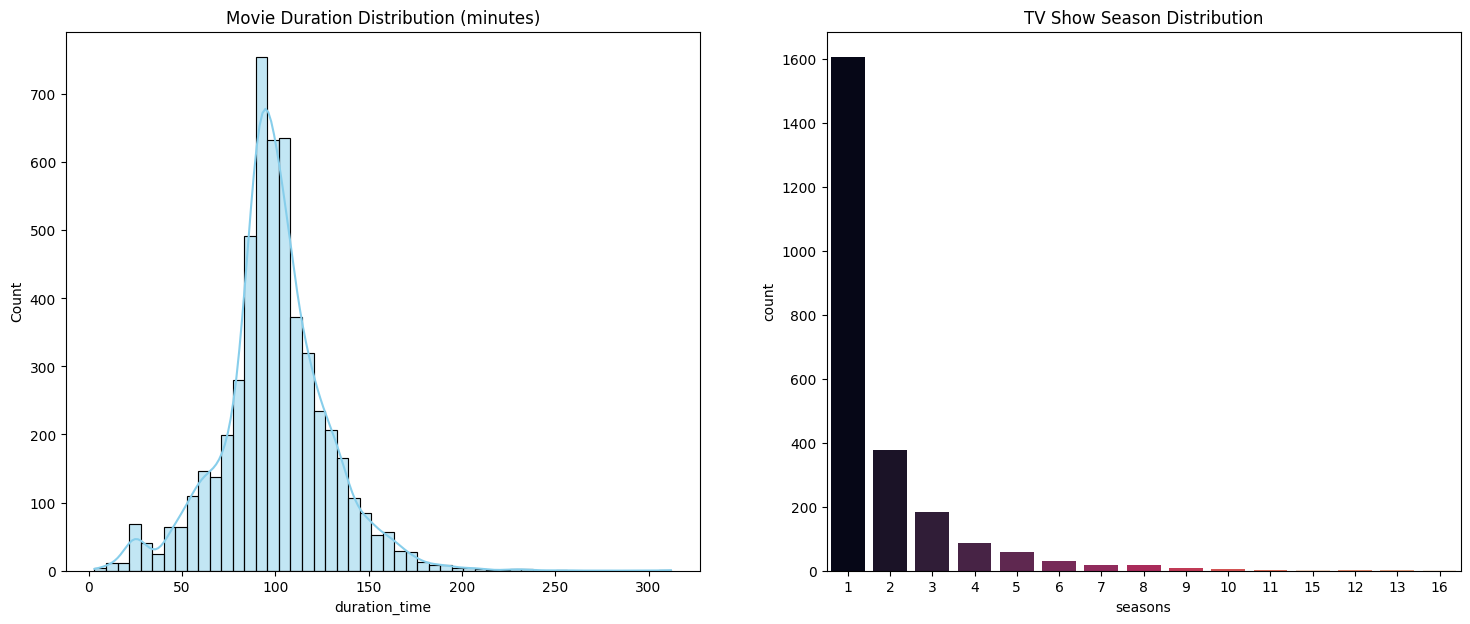

In [ ]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_time', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

Insights :

---
- Movie time duration got a normal distribution where 80-120 min has got the highest count
- Maximum TV Shows ends up within one season



**Q.5 Where does the content come from? (Geographical Analysis)**

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


In [ ]:
# Find the Countries with most contents

df['country'].value_counts()

# here the values

,count
country,
United States,3051
India,923
United Kingdom,396
Japan,224
South Korea,183
...,...
"Germany, United States, United Kingdom, Canada",1
"Peru, United States, United Kingdom",1
"Saudi Arabia, United Arab Emirates",1


In [ ]:
countries= df.assign(country=df['country'].str.split(', ')).explode('country')
countries["country"].value_counts()

,count
country,
United States,3792
India,990
United Kingdom,721
Canada,412
France,349
...,...
Panama,1
"United Kingdom,",1
Uganda,1


In [ ]:
top_countries = countries['country'].value_counts().reset_index()
top_countries

,country,count
0,United States,3792
1,India,990
2,United Kingdom,721
3,Canada,412
4,France,349
...,...,...
116,Panama,1
117,"United Kingdom,",1
118,Uganda,1
119,East Germany,1


Text(0, 0.5, 'Country')

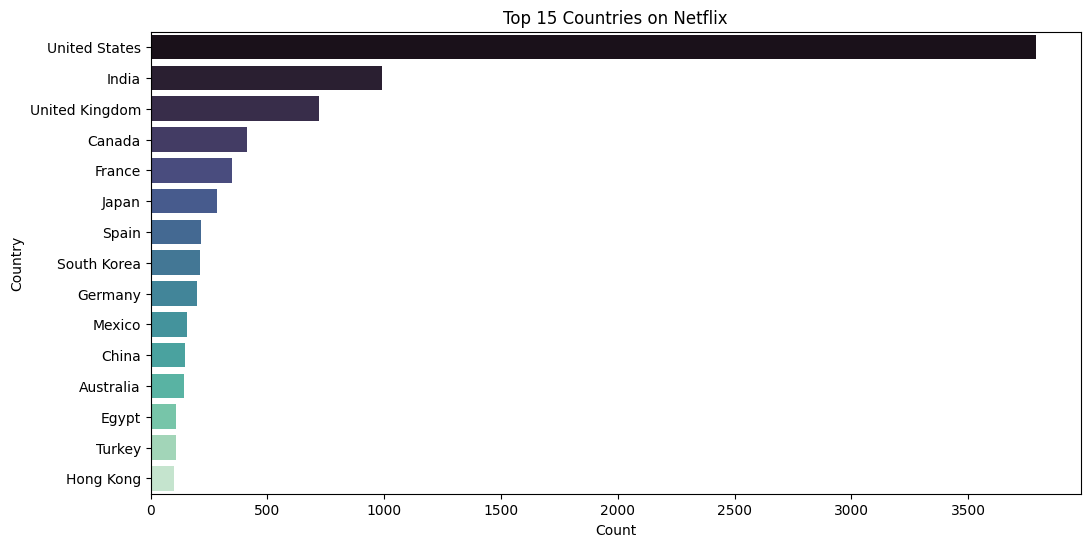

In [ ]:
top_15_countries = top_countries.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y='country', x='count', data=top_15_countries, palette='mako', hue='country', legend=False)
plt.title('Top 15 Countries on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')

Insights:

---



---
- Most of the contents are from US followed by India , UK and Canada



**Q.6 What are the maturity ratings of the content?**

In [ ]:

content_ratings = df['rating'].value_counts()
content_ratings

,count
rating,
TV-MA,2861
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


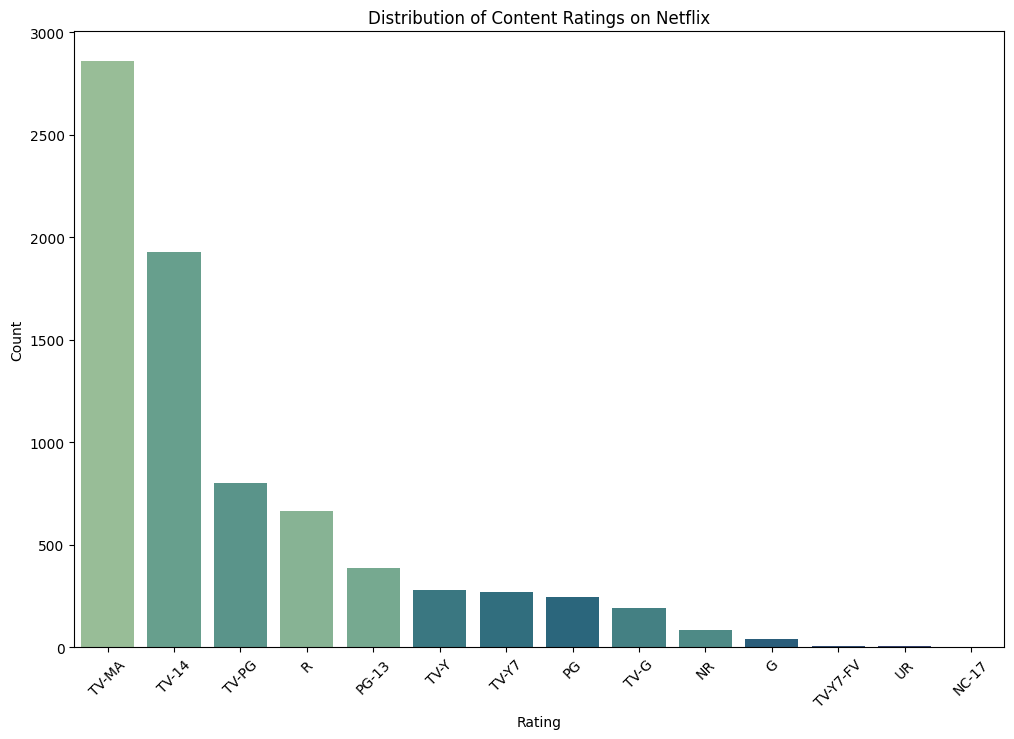

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insights :


---
-  TV_MA has the highest count followed by TV-14 , TV-PG




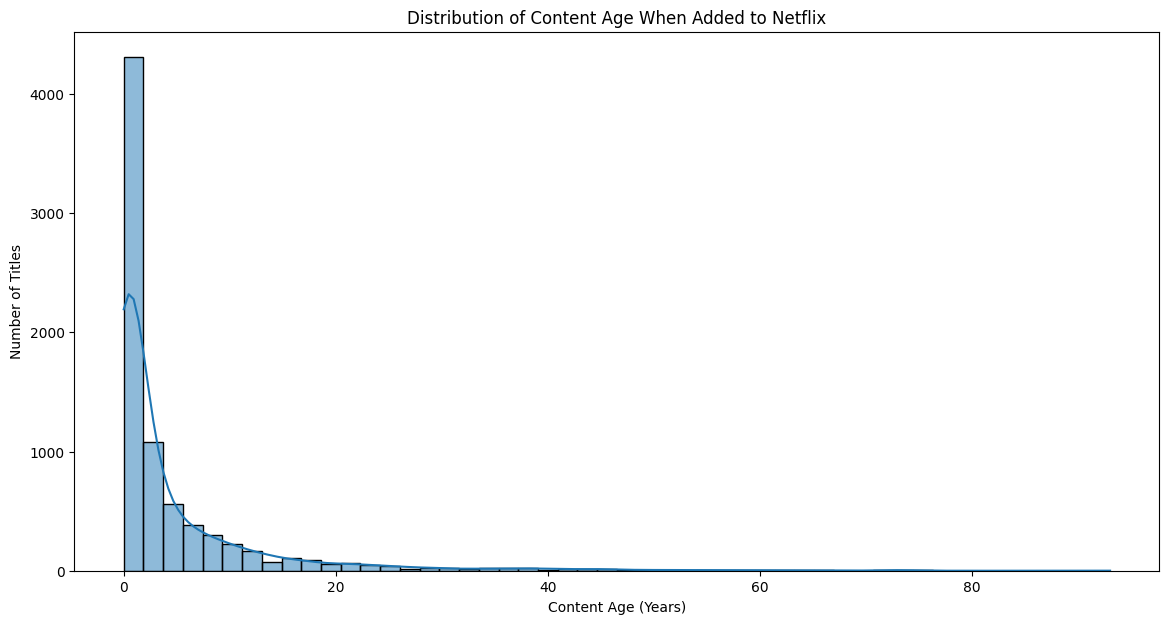

In [ ]:
# Create the 'age_on_netflix' feature
df['age_on_netflix'] = df['year_added'] - df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = df[df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

Insights :

---
- Maximum of the content was added into netflix in the same year it was released .
- Netflix also got decades of years old content making sure variety




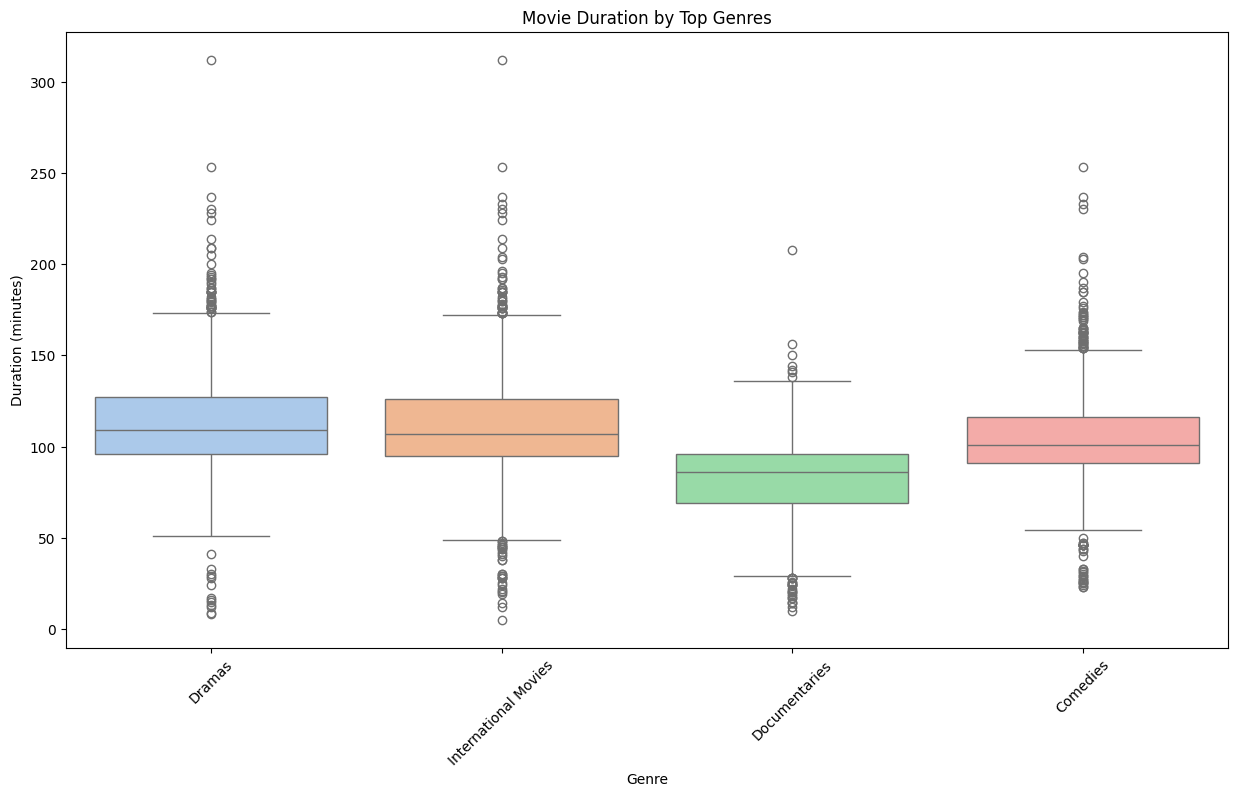

In [ ]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

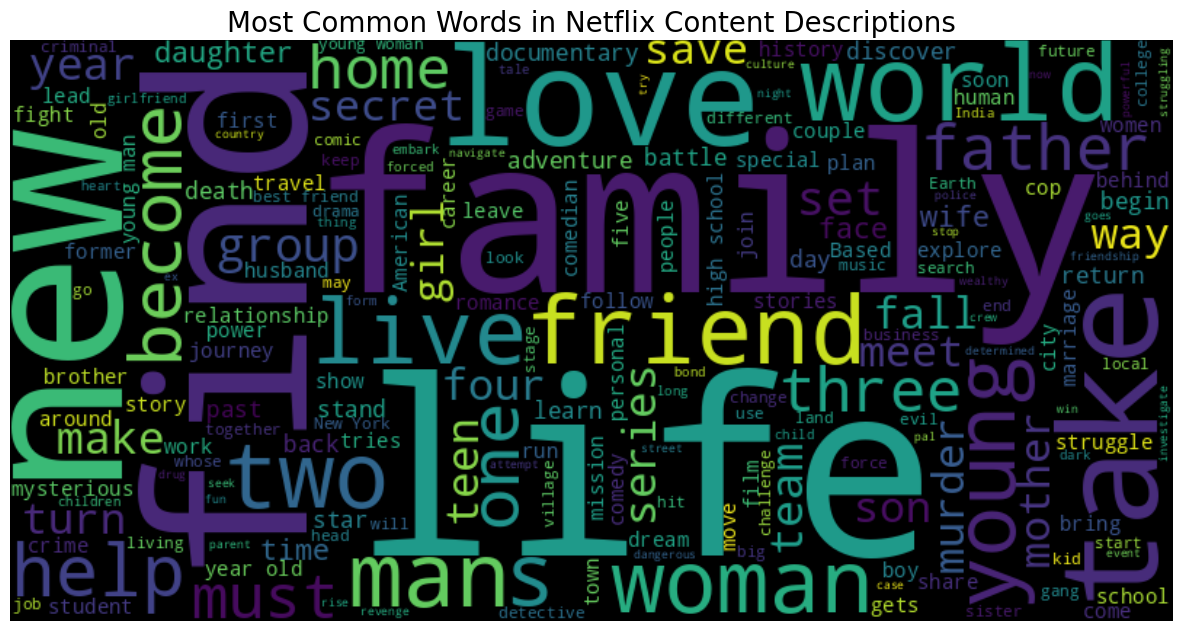

In [ ]:
from wordcloud import WordCloud
# Combine all descriptions into a single string
text = ' '.join(df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

# **Assisgnment Solutions: **

- How has the distribution of content ratings changed over time?  
- Is there a relationship between content age and its type (Movie vs. TV Show)?  
- Can we identify any trends in content production based on the release year vs. the year added to Netflix?  
- What are the most common word pairs or phrases in content descriptions?  
- Who are the top directors on Netflix?

# **AQ.1 How has the distribution of content ratings changed over time?**

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,2861
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


In [ ]:
rating_over_time= df.groupby(['year_added' , 'rating']).size().unstack().fillna(0)
rating_over_time


rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
year_added,,,,,,,,,,,,,,
2008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0
2012,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2013,0.0,0.0,4.0,1.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0
2014,1.0,0.0,0.0,3.0,0.0,0.0,2.0,1.0,12.0,4.0,2.0,0.0,0.0,0.0
2015,1.0,0.0,5.0,2.0,2.0,3.0,15.0,8.0,29.0,8.0,8.0,5.0,2.0,0.0
2016,2.0,1.0,28.0,3.0,6.0,14.0,103.0,9.0,163.0,53.0,11.0,46.0,1.0,0.0


<Figure size 1400x600 with 0 Axes>

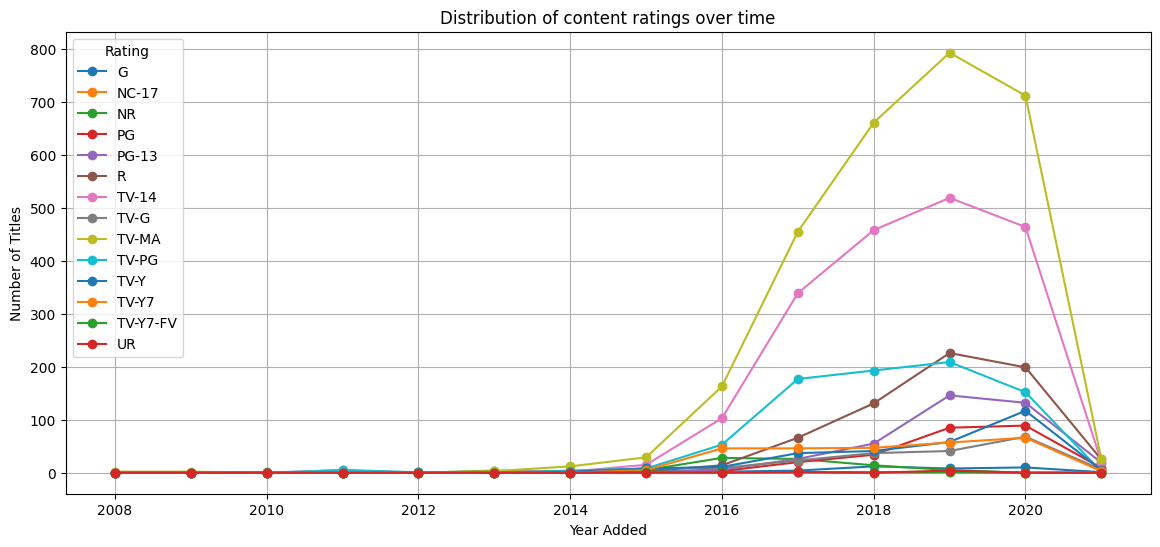

In [ ]:
plt.figure(figsize=(14 , 6))
rating_over_time.plot(kind="line" , marker="o" , figsize=(14 , 6))
plt.title("Distribution of content ratings over time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Rating")
plt.grid(True)
plt.show()

<Figure size 1400x600 with 0 Axes>

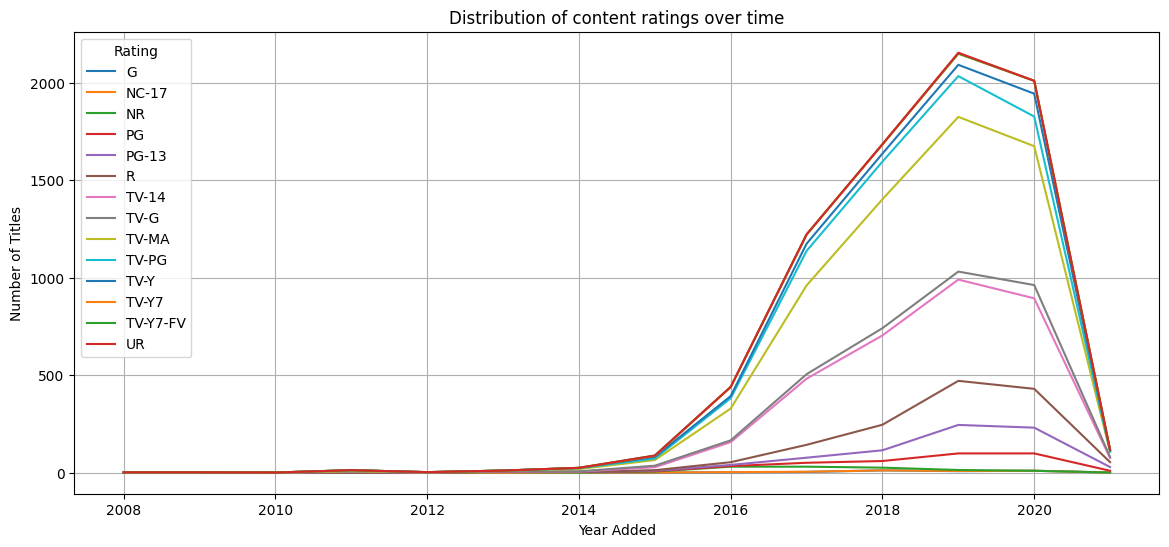

In [ ]:
#This represents the stacked line graph

plt.figure(figsize=(14 , 6))
rating_over_time.plot(kind="line" ,stacked=True , figsize=(14 , 6))
plt.title("Distribution of content ratings over time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Rating")
plt.grid(True)
plt.show()

# **AQ.2 Is there a relationship between content age and its type (Movie vs. TV Show)?**

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,age_on_netflix
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0


<Axes: xlabel='release_year', ylabel='Count'>

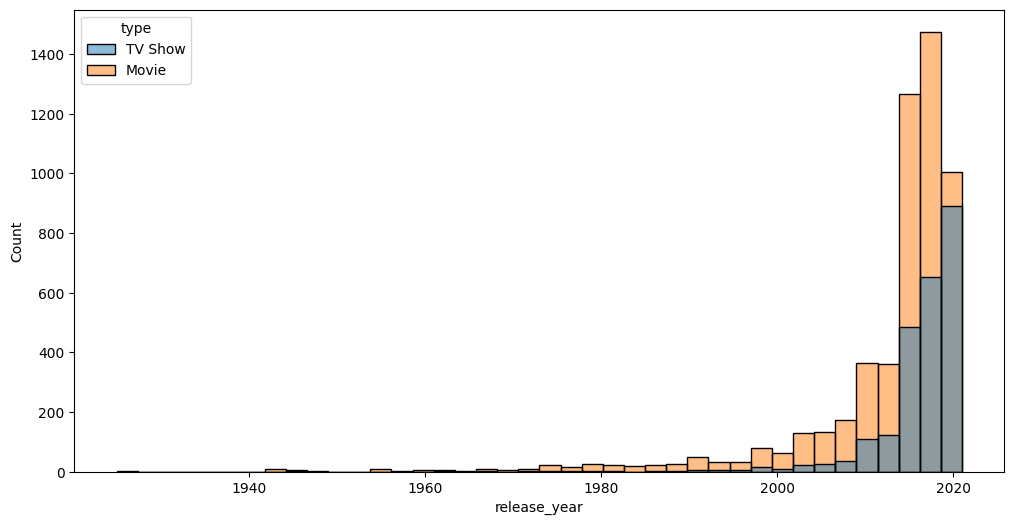

In [ ]:
plt.figure(figsize=(12 , 6))
sns.histplot(x="release_year" , data=df  , hue="type" , bins=40)
plt.title("Content Type vs Content Rea")
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

Insight:

---
- Netflix includes the older movies along with the new ones however , it has more recent TV shows and fewer older ones. This may indicate that the recent TV shows are becoming popular in the platform in recent times.



# **AQ.3 Can we identify any trends in content production based on the release year vs. the year added to Netflix?**


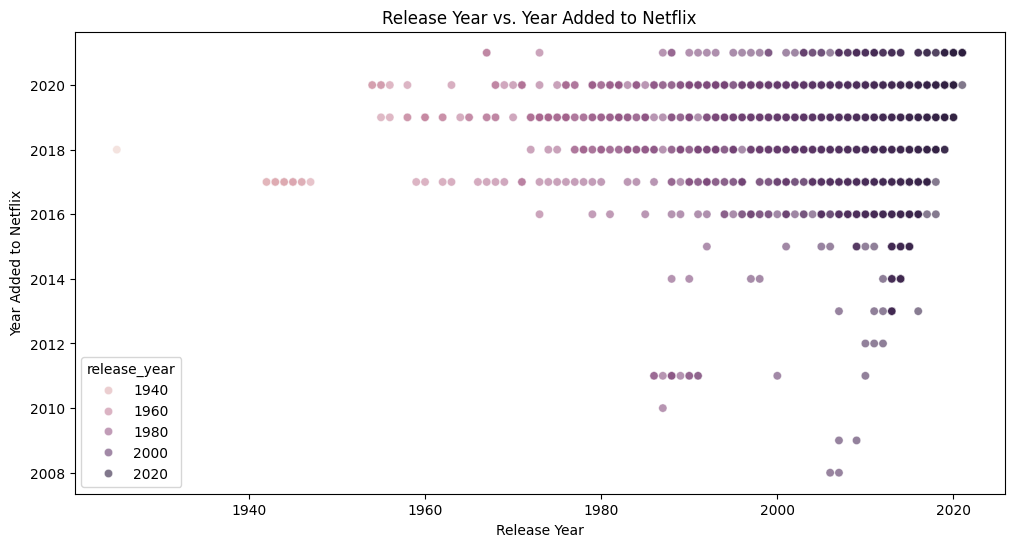

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='release_year', y='year_added', alpha=0.6, hue='release_year')
plt.title('Release Year vs. Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

Insights :


---
- Netflix adds both the recent and older content, keeping the variety. However , in recent times, Netflix has been more focused on newly released content.



# **AQ.4 What are the most common word pairs or phrases in content descriptions?**


# **AQ.5 Who are the top directors on Netflix?**

In [ ]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,age_on_netflix
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0


In [ ]:
df['director'].value_counts()

,count
director,
Unknown,2376
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
...,...
John Trengove,1
Jonathan Helpert,1
Jacob Schwab,1


In [ ]:
top_directors= df.assign(director=df['director'].str.split(', ')).explode('director')
top_directors["director"].value_counts()

,count
director,
Unknown,2376
Jan Suter,21
Raúl Campos,19
Marcus Raboy,16
Jay Karas,15
...,...
Shravan Kumar,1
Shane Acker,1
Gilbert Chan,1


In [ ]:
top_15_director= top_directors['director'].value_counts().reset_index().head(16)
top_15_director.columns=['director' , 'count']
top_15_director= top_15_director.drop(index=0)
top_15_director

,director,count
1,Jan Suter,21
2,Raúl Campos,19
3,Marcus Raboy,16
4,Jay Karas,15
5,Cathy Garcia-Molina,13
6,Youssef Chahine,12
7,Martin Scorsese,12
8,Jay Chapman,12
9,Steven Spielberg,10
10,Anurag Kashyap,9


In [ ]:
top_15_director.head()

,director,count
1,Jan Suter,21
2,Raúl Campos,19
3,Marcus Raboy,16
4,Jay Karas,15
5,Cathy Garcia-Molina,13


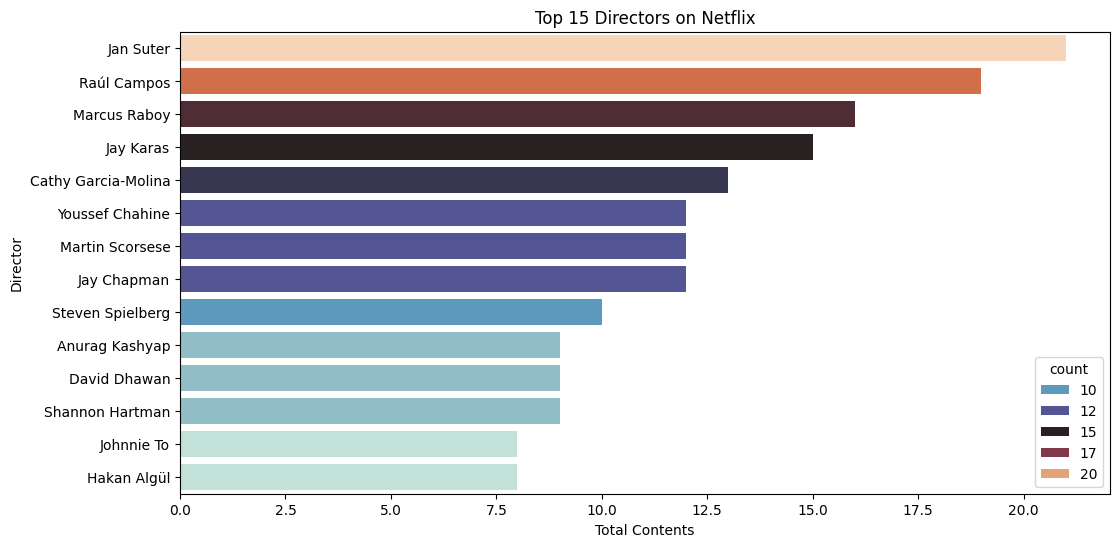

In [ ]:
plt.figure(figsize=(12 ,6))
sns.barplot(x="count" , y="director" , data=top_15_director , palette="icefire" , hue="count", order=top_10_director["director"].value_counts().index)
plt.xlabel("Total Contents")
plt.ylabel("Director")
plt.title("Top 15 Directors on Netflix")
plt.show()

Insights :

---
- Jan Suter is the top director on netflix with more than 20 Contents followed by Raul Campos and Marcus Raboy.


